In [11]:
import os 
import numpy as np 
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [12]:
# --- Inputs ---
MASTER_CSV = os.path.join("..", "Data", "Project_Areas_WWOL_Master - Project_Areas_WWOL_Master.csv") 
master = pd.read_csv(MASTER_CSV)
costs = pd.read_csv(os.path.join("..", "Data", "Project_Areas_WWOL_Master - Costs.csv"))

In [13]:

STATEWIDE = 83421
order = ["Planned or Underway (P)", "Under Evaluation (E)", "No Active Plans (N)"]

g = master.groupby("Status").agg(Areas=("UID","count"), Cesspools=("Total_Cesspools","sum")).reindex(order)
g.loc["Total"] = g.sum()
g["% PA"] = (g["Cesspools"] / g.loc["Total","Cesspools"] * 100).round(1)
g["% SW"] = (g["Cesspools"] / STATEWIDE * 100).round(1)

print(g.to_csv(sep="\t"))

Status	Areas	Cesspools	% PA	% SW
Planned or Underway (P)	4	1115	2.8	1.3
Under Evaluation (E)	32	6958	17.7	8.3
No Active Plans (N)	67	31238	79.5	37.4
Total	103	39311	100.0	47.1



### Fig 7 

Planning Status             Areas   Cesspools    % PA    % SW
Planned or Underway (P)         4       1,115    2.8%    1.3%
Under Evaluation (E)           32       6,958   17.7%    8.3%
No Active Plans (N)            67      31,238   79.5%   37.4%
Total                         103      39,311  100.0%   47.1%


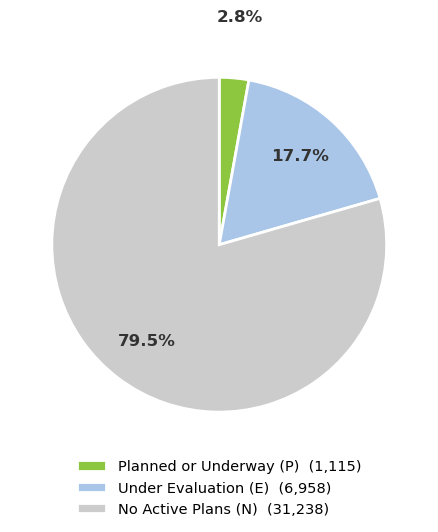

In [8]:
# ----------------------------------------------------------------------
# Section 2: Statewide Planning Status
# Reads the master sheet and produces (1) a summary table and (2) a pie chart.
# Re-run as-is after any county revision; all numbers recompute from the data.
# ----------------------------------------------------------------------
STATEWIDE_TOTAL = 83421   # total statewide cesspool inventory (HCPT)

master = pd.read_csv(MASTER_CSV)

# Fixed status order and app legend colors (Planned, Evaluation, No Plans)
status_order = ["Planned or Underway (P)", "Under Evaluation (E)", "No Active Plans (N)"]
colors = {"Planned or Underway (P)": "#8dc63f",
          "Under Evaluation (E)":    "#a9c6e8",
          "No Active Plans (N)":     "#cccccc"}

# --- Build summary table ---
g = (master.groupby("Status")
           .agg(Project_Areas=("UID", "count"),
                Cesspools=("Total_Cesspools", "sum"))
           .reindex(status_order)
           .reset_index())

pa_total = g["Cesspools"].sum()
g["Pct_Project_Area"] = g["Cesspools"] / pa_total * 100
g["Pct_Statewide"]    = g["Cesspools"] / STATEWIDE_TOTAL * 100

# Print a clean table
print(f"{'Planning Status':<26}{'Areas':>7}{'Cesspools':>12}{'% PA':>8}{'% SW':>8}")
for _, r in g.iterrows():
    print(f"{r['Status']:<26}{r['Project_Areas']:>7}{r['Cesspools']:>12,}"
          f"{r['Pct_Project_Area']:>7.1f}%{r['Pct_Statewide']:>7.1f}%")
print(f"{'Total':<26}{g['Project_Areas'].sum():>7}{pa_total:>12,}"
      f"{100:>7.1f}%{pa_total/STATEWIDE_TOTAL*100:>7.1f}%")

# --- Pie chart ---
plt.rcParams["font.family"] = "DejaVu Sans"
fig, ax = plt.subplots(figsize=(7, 5.5))

wedges, _, autotexts = ax.pie(
    g["Cesspools"],
    colors=[colors[s] for s in g["Status"]],
    autopct=lambda p: f"{p:.1f}%",
    startangle=90, counterclock=False,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    pctdistance=0.72,
    textprops=dict(fontsize=12, fontweight="bold", color="#333333"),
)

# Push the smallest wedge's % label outside so it stays legible
smallest = g["Cesspools"].idxmin()
x, y = autotexts[smallest].get_position()
autotexts[smallest].set_position((x * 1.9, y * 1.9))

ax.legend(wedges,
          [f"{s}  ({c:,})" for s, c in zip(g["Status"], g["Cesspools"])],
          loc="lower center", bbox_to_anchor=(0.5, -0.18),
          frameon=False, fontsize=10.5)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(os.path.join(".", "Figures", "planning_status_pie.png"), dpi=300, bbox_inches="tight", facecolor="white")

### Fig 8

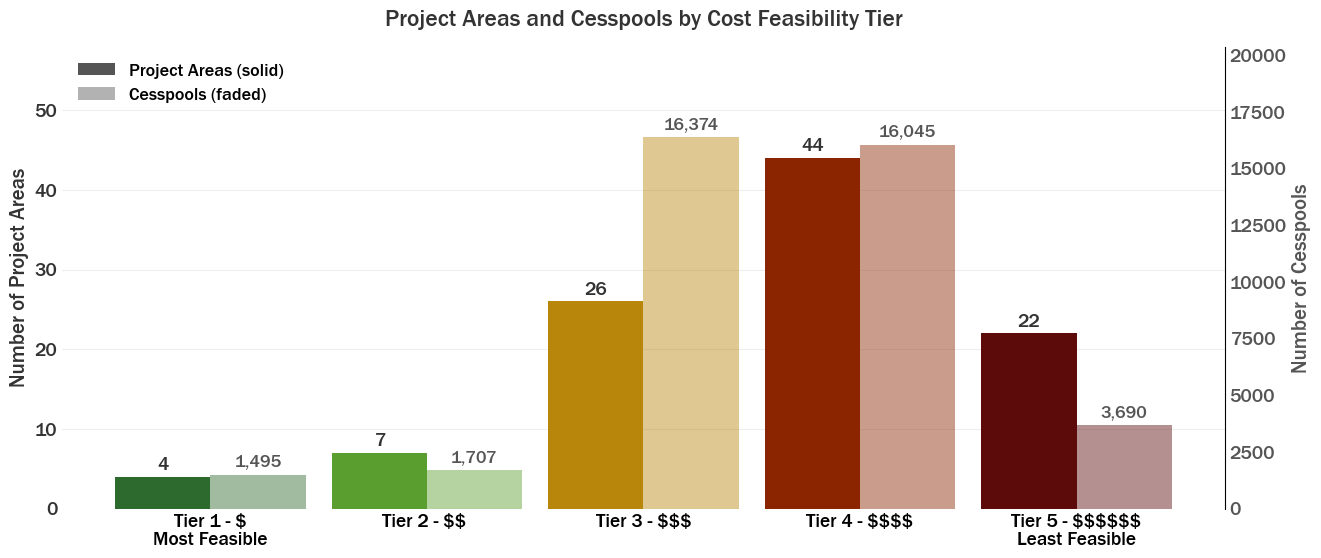

In [14]:
mpl.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "Franklin Gothic Medium"
plt.rcParams["font.size"] = 14

tier_order  = ["(1) - $", "(2) - $$", "(3) - $$$", "(4) - $$$$", "(5) - $$$$$"]
tier_labels = ["Tier 1 - $\nMost Feasible", "Tier 2 - $\$ ", "Tier 3 - $\$\$", "Tier 4 - $\$\$\$", "Tier 5 - $\$\$\$\$\$\nLeast Feasible"]
tier_colors = ["#2d6a2d", "#5a9e2f", "#b8860b", "#8b2500", "#5c0a0a"]

merged_tiers = master[["UID", "Total_Cesspools"]].merge(costs[["UID", "Cost_symbol"]], on="UID")
areas_by_tier = costs["Cost_symbol"].value_counts().reindex(tier_order)
pools_by_tier = merged_tiers.groupby("Cost_symbol")["Total_Cesspools"].sum().reindex(tier_order)

x     = np.arange(len(tier_labels))
width = 0.44

fig, ax1 = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

bars1 = ax1.bar(x - width/2, areas_by_tier.values, width, color=tier_colors, edgecolor="none", label="Project Areas", zorder=3)
ax1.set_ylabel("Number of Project Areas", fontsize=15, color="#333333")
ax1.tick_params(axis="y", labelcolor="#333333", length=0, labelsize=14)
ax1.set_ylim(0, areas_by_tier.max() + 14)

for bar, val in zip(bars1, areas_by_tier.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha="center", va="bottom", fontsize=14, fontweight="bold", color="#333333")

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, pools_by_tier.values, width, color=tier_colors, edgecolor="none", alpha=0.45, zorder=3)
ax2.set_ylabel("Number of Cesspools", fontsize=15, color="#555555")
ax2.tick_params(axis="y", labelcolor="#555555", length=0, labelsize=14)
ax2.set_ylim(0, pools_by_tier.max() + 4000)
ax2.yaxis.grid(False)

for bar, val in zip(bars2, pools_by_tier.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{val:,}", ha="center", va="bottom", fontsize=13, fontweight="bold", color="#555555")

ax1.set_xticks(x)
ax1.set_xticklabels(tier_labels, fontsize=14)
ax1.set_title("Project Areas and Cesspools by Cost Feasibility Tier", fontsize=17, fontweight="bold", color="#333333", pad=15)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#555555", label="Project Areas (solid)"),
                   Patch(facecolor="#555555", alpha=0.45, label="Cesspools (faded)")]
ax1.legend(handles=legend_elements, loc="upper left", frameon=False, fontsize=13)

ax1.yaxis.grid(True, color="#eeeeee", zorder=0)
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)
for spine in ["top", "left", "bottom"]:
    ax1.spines[spine].set_visible(False)
for spine in ["top", "right", "left", "bottom"]:
    ax2.spines[spine].set_visible(False)
ax1.tick_params(axis="x", length=0)

fig.savefig(os.path.join(".", "Figures", "cost_tier_dual.png"), dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [15]:
tier_order = ["(1) - $", "(2) - $$", "(3) - $$$", "(4) - $$$$", "(5) - $$$$$"]
counts = costs["Cost_symbol"].value_counts().reindex(tier_order)

t12  = counts[["(1) - $", "(2) - $$"]].sum()
t3   = counts["(3) - $$$"]
t45  = counts[["(4) - $$$$", "(5) - $$$$$"]].sum()
total = counts.sum()

print(f"Of the {total} project areas, only {t12} fall in the two most feasible tiers. "
      f"Another {t3} areas fall in Tier 3, with the majority, {t45} project areas, "
      f"sitting in Tiers 4 and 5, the least feasible.")


Of the 103 project areas, only 11 fall in the two most feasible tiers. Another 26 areas fall in Tier 3, with the majority, 66 project areas, sitting in Tiers 4 and 5, the least feasible.


### Fig 9

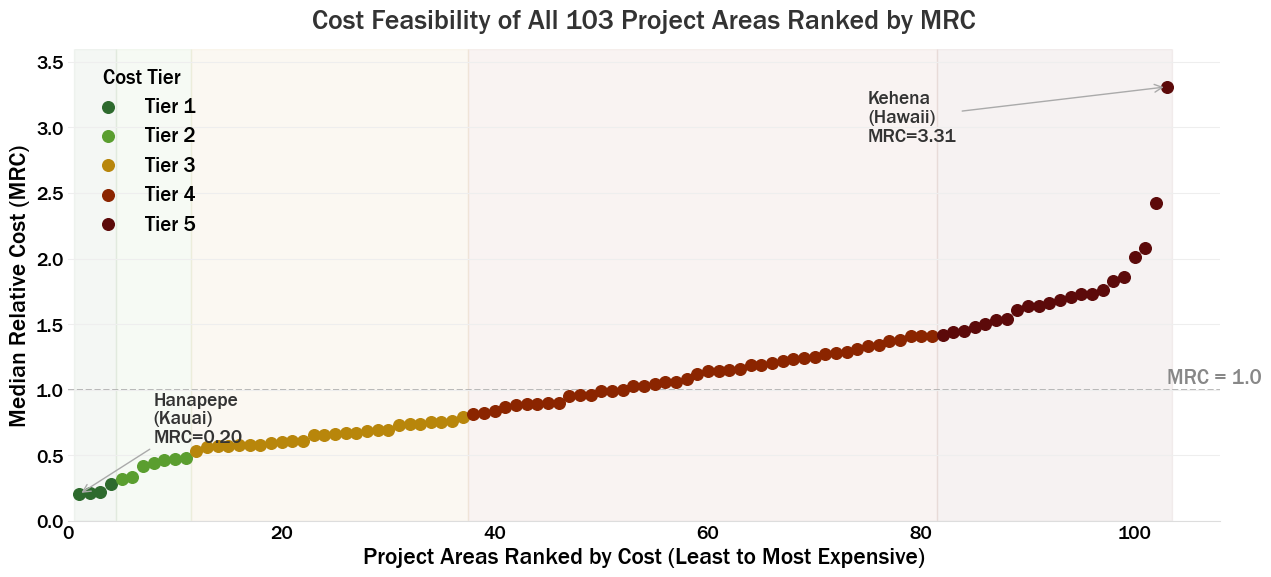

In [16]:
mrc_col = 'MRC: Median Relative Cost (dimensionless) '

merged_mrc = costs.merge(master[['UID','island']], on='UID')
merged_mrc['CPC_num'] = merged_mrc['Cost_per_Connection'].replace('[\$,]','',regex=True).astype(float)
df_ranked = merged_mrc[['Name','island','Cost_symbol', mrc_col, 'CPC_num']].sort_values('CPC_num').reset_index(drop=True)
df_ranked['rank'] = range(1, len(df_ranked)+1)

tier_colors = {
    '(1) - $':     '#2d6a2d',
    '(2) - $$':    '#5a9e2f',
    '(3) - $$$':   '#b8860b',
    '(4) - $$$$':  '#8b2500',
    '(5) - $$$$$': '#5c0a0a',
}
tier_labels_map = {
    '(1) - $':     'Tier 1',
    '(2) - $$':    'Tier 2',
    '(3) - $$$':   'Tier 3',
    '(4) - $$$$':  'Tier 4',
    '(5) - $$$$$': 'Tier 5',
}

tier_order = ['(1) - $','(2) - $$','(3) - $$$','(4) - $$$$','(5) - $$$$$']
counts = df_ranked['Cost_symbol'].value_counts().reindex(tier_order)
bounds = [0]
for c in counts:
    bounds.append(bounds[-1] + c)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

tier_cols = ['#2d6a2d','#5a9e2f','#b8860b','#8b2500','#5c0a0a']
for i, (start, end) in enumerate(zip(bounds[:-1], bounds[1:])):
    ax.axvspan(start+0.5, end+0.5, alpha=0.05, color=tier_cols[i], zorder=0)

for tier, color in tier_colors.items():
    subset = df_ranked[df_ranked['Cost_symbol'] == tier]
    ax.scatter(subset['rank'], subset[mrc_col], color=color, s=70,
               zorder=3, label=tier_labels_map[tier])

ax.axhline(1.0, color='#aaaaaa', linewidth=1.2, linestyle='--', zorder=0)
ax.text(103, 1.02, 'MRC = 1.0', fontsize=15, color='#888888', va='bottom')

cheapest = df_ranked.iloc[0]
expensive = df_ranked.iloc[-1]
ax.annotate(f"{cheapest['Name']}\n({cheapest['island']})\nMRC={cheapest[mrc_col]:.2f}",
            xy=(cheapest['rank'], cheapest[mrc_col]),
            xytext=(8, 0.6), fontsize=14, color='#333333',
            arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1))
ax.annotate(f"{expensive['Name']}\n({expensive['island']})\nMRC={expensive[mrc_col]:.2f}",
            xy=(expensive['rank'], expensive[mrc_col]),
            xytext=(75, 2.9), fontsize=14, color='#333333',
            arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1))

ax.set_xlabel('Project Areas Ranked by Cost (Least to Most Expensive)', fontsize=17)
ax.set_ylabel('Median Relative Cost (MRC)', fontsize=17)
ax.set_title('Cost Feasibility of All 103 Project Areas Ranked by MRC', fontsize=20,
             fontweight='bold', color='#333333', pad=15)
ax.tick_params(labelsize=14, length=0)
ax.set_xlim(0, 108)
ax.set_ylim(0, 3.6)
ax.yaxis.grid(True, color='#eeeeee', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#dddddd')
ax.legend(title='Cost Tier', loc='upper left', frameon=False, fontsize=15, title_fontsize=15)

plt.tight_layout()
fig.savefig(os.path.join(".", "Figures", "mrc_ranked.png"), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


### Table 7

In [20]:
island_order  = ['Hawaii', 'Maui', 'Molokai', 'Oahu', 'Kauai']
island_labels = ["Hawai'i Island", 'Maui', "Moloka'i", "O'ahu", "Kaua'i"]
mrc_col = 'MRC: Median Relative Cost (dimensionless) '
tier_order = ['(1) - $','(2) - $$','(3) - $$$','(4) - $$$$','(5) - $$$$$']

merged_geo = costs.merge(master[['UID','island','Cost_symbol','Total_Cesspools']], on='UID', suffixes=('_costs','_master'))

areas_pivot = merged_geo.groupby(['island','Cost_symbol_master']).size().unstack(fill_value=0).reindex(index=island_order, columns=tier_order, fill_value=0)
cp_total    = merged_geo.groupby('island')['Total_Cesspools'].sum().reindex(island_order)
area_total  = merged_geo.groupby('island').size().reindex(island_order)
mrc_median  = merged_geo.groupby('island')[mrc_col].median().reindex(island_order)

# Print tab-separated for Google Sheets paste
header = ['Island', 'Tier 1', 'Tier 2', 'Tier 3', 'Tier 4', 'Tier 5', 'Total Areas', 'Total Cesspools', 'Median MRC']
print('\t'.join(header))

for isl, lbl in zip(island_order, island_labels):
    row = [lbl] + [str(areas_pivot.loc[isl, t]) if areas_pivot.loc[isl, t] > 0 else '-' for t in tier_order]
    row += [str(int(area_total[isl])), f"{int(cp_total[isl]):,}", f"{mrc_median[isl]:.2f}"]
    print('\t'.join(row))

# Total row
totals = areas_pivot.sum()
print('\t'.join(
    ['Total'] +
    [str(int(totals[t])) for t in tier_order] +
    [str(int(area_total.sum())), f"{int(cp_total.sum()):,}", f"{merged_geo[mrc_col].median():.2f}"]
))

Island	Tier 1	Tier 2	Tier 3	Tier 4	Tier 5	Total Areas	Total Cesspools	Median MRC
Hawai'i Island	-	1	10	16	15	42	20,003	1.29
Maui	1	1	6	4	4	16	5,103	0.82
Moloka'i	-	-	-	1	1	2	381	1.69
O'ahu	2	4	4	11	1	22	4,425	0.90
Kaua'i	1	1	6	12	1	21	9,399	0.84
Total	4	7	26	44	22	103	39,311	1.00


### Cleaner Table 7? 

In [34]:
# Build island summary table
mrc_col = 'MRC: Median Relative Cost (dimensionless) '

# Merge costs into master
df_summary = master.merge(costs[['UID', mrc_col, 'Cost_symbol']], on='UID', how='left', suffixes=('', '_costs'))

# Extract tier number from Cost_symbol
df_summary['tier'] = df_summary['Cost_symbol_costs'].str.extract(r'\((\d)\)').astype(float)

# Island display order
island_order = ['Hawaii', 'Maui', 'Molokai', 'Oahu', 'Kauai']
island_display = {"Hawaii": "Hawai'i Island", 'Maui': 'Maui', 
                  'Molokai': "Moloka'i", 'Oahu': "O'ahu", 'Kauai': "Kaua'i"}

rows = []
for island in island_order:
    sub = df_summary[df_summary['island'] == island]
    row = {
        'Island': island_display[island],
        'Total Areas': len(sub),
        'Tier 1': (sub['tier'] == 1).sum(),
        'Tier 2': (sub['tier'] == 2).sum(),
        'Tier 3': (sub['tier'] == 3).sum(),
        'Tier 4': (sub['tier'] == 4).sum(),
        'Tier 5': (sub['tier'] == 5).sum(),
        'Total Cesspools': sub['Total_Cesspools'].sum(),
        'Median MRC': round(sub[mrc_col].median(), 2)
    }
    rows.append(row)

# Add total row
rows.append({
    'Island': 'Total',
    'Total Areas': len(df_summary),
    'Tier 1': (df_summary['tier'] == 1).sum(),
    'Tier 2': (df_summary['tier'] == 2).sum(),
    'Tier 3': (df_summary['tier'] == 3).sum(),
    'Tier 4': (df_summary['tier'] == 4).sum(),
    'Tier 5': (df_summary['tier'] == 5).sum(),
    'Total Cesspools': df_summary['Total_Cesspools'].sum(),
    'Median MRC': round(df_summary[mrc_col].median(), 2)
})

island_table = pd.DataFrame(rows)

# Replace 0 with dash for display
tier_cols = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4', 'Tier 5']
island_table[tier_cols] = island_table[tier_cols].replace(0, '-')

island_table

,Island,Total Areas,Tier 1,Tier 2,Tier 3,Tier 4,Tier 5,Total Cesspools,Median MRC
0,Hawai'i Island,42,-,1,10,16,15,20003,1.29
1,Maui,16,1,1,6,4,4,5103,0.82
2,Moloka'i,2,-,-,-,1,1,381,1.69
3,O'ahu,22,2,4,4,11,1,4425,0.90
4,Kaua'i,21,1,1,6,12,1,9399,0.84
5,Total,103,4,7,26,44,22,39311,1.00


### Fig 13

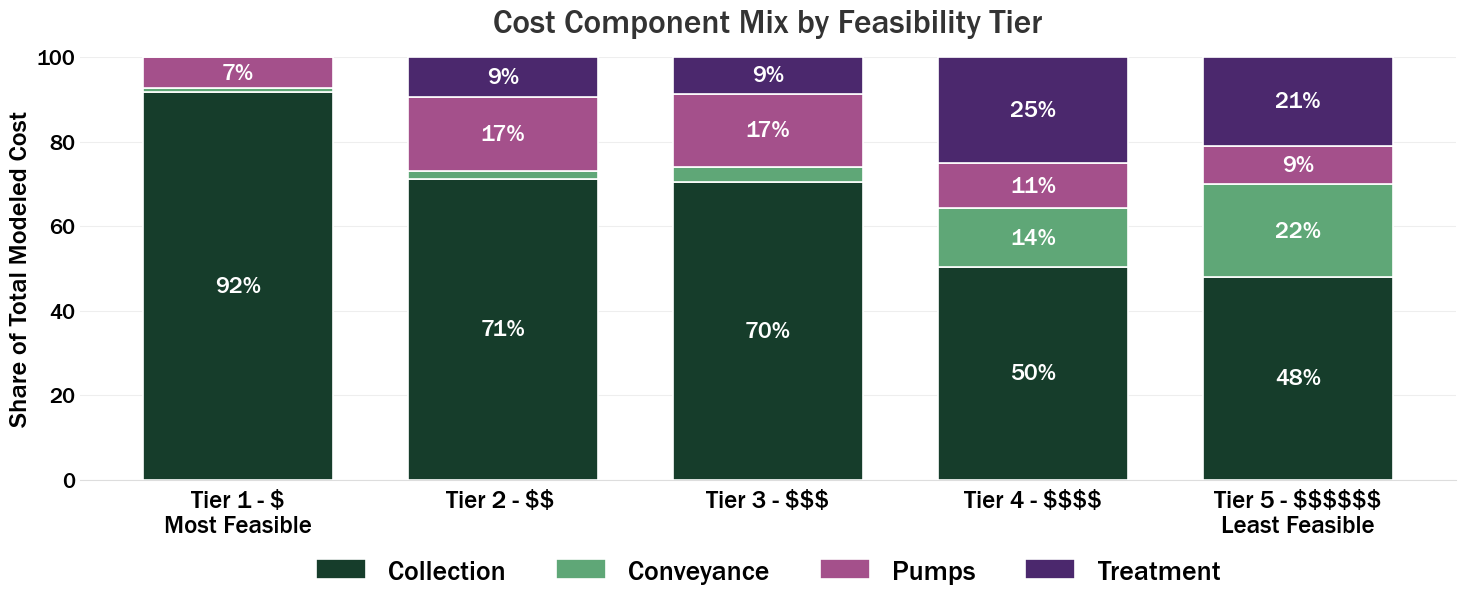

Saved cost_component_mix_by_tier.png
Tier	Collection	Conveyance	Pumps	Treatment
"Tier 1 - $
Most Feasible"	91.8	0.9	7.4	0.0
Tier 2 - $\$ 	71.3	1.9	17.5	9.4
Tier 3 - $\$\$	70.4	3.7	17.3	8.6
Tier 4 - $\$\$\$	50.2	14.0	10.6	25.1
"Tier 5 - $\$\$\$\$\$
Least Feasible"	47.8	22.1	9.0	21.0



In [23]:
# Cost component mix by feasibility tier
mpl.rcParams["text.usetex"] = False; plt.rcParams.update({"font.family": "Franklin Gothic Medium", "font.size": 18})
tier_order = ["(1) - $", "(2) - $$", "(3) - $$$", "(4) - $$$$", "(5) - $$$$$"]

tier_labels = ["Tier 1 - $\nMost Feasible", "Tier 2 - $\$ ", "Tier 3 - $\$\$", "Tier 4 - $\$\$\$", "Tier 5 - $\$\$\$\$\$\nLeast Feasible"]

components = ["Collection", "Conveyance", "Pumps", "Treatment"]; colors = {"Collection": "#163D2B", "Conveyance": "#5FA777", "Pumps": "#A4508B", "Treatment": "#4B286D"}

for c in ["Collection_Cost", "Conveyance_Cost", "Treatment_Cost", "Neighborhood_Pump_Cost", "Regional_Pump_Cost"]: costs[c + "_num"] = costs[c].replace(r"[\$,]", "", regex=True).astype(float)
costs["Pumps_num"] = costs["Neighborhood_Pump_Cost_num"] + costs["Regional_Pump_Cost_num"]

df = pd.DataFrame([{"Tier": tier_labels[i], "Collection": costs.loc[costs.Cost_symbol.eq(t), "Collection_Cost_num"].sum(), "Conveyance": costs.loc[costs.Cost_symbol.eq(t), "Conveyance_Cost_num"].sum(), "Pumps": costs.loc[costs.Cost_symbol.eq(t), "Pumps_num"].sum(), "Treatment": costs.loc[costs.Cost_symbol.eq(t), "Treatment_Cost_num"].sum()} for i, t in enumerate(tier_order)])
df[components] = df[components].div(df[components].sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(15, 6.5), facecolor="white"); ax.set_facecolor("white"); bottom = np.zeros(len(df))
for comp in components:
    vals = df[comp].values; bars = ax.bar(df["Tier"], vals, bottom=bottom, color=colors[comp], edgecolor="white", linewidth=1.2, label=comp, width=0.72, zorder=3)
    for bar, val, b in zip(bars, vals, bottom):
        if val >= 7: ax.text(bar.get_x() + bar.get_width()/2, b + val/2, f"{val:.0f}%", ha="center", va="center", fontsize=17, fontweight="bold", color="white")
    bottom += vals

ax.set(ylabel="Share of Total Modeled Cost", ylim=(0, 100)); ax.set_title("Cost Component Mix by Feasibility Tier", fontsize=24, fontweight="bold", color="#333333", pad=18)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=4, frameon=False, fontsize=20, handlelength=1.8, columnspacing=1.8); ax.grid(axis="y", color="#eeeeee", zorder=0); ax.set_axisbelow(True)
for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#dddddd"); ax.tick_params(axis="x", length=0, labelsize=18, pad=8); ax.tick_params(axis="y", length=0, labelsize=16)
ax.yaxis.label.set_size(19)
plt.tight_layout(); fig.savefig(os.path.join(".", "Figures", "cost_component_mix_by_tier.png"), dpi=300, bbox_inches="tight", facecolor="white"); plt.show()
print("Saved cost_component_mix_by_tier.png"); print(df[["Tier"] + components].round(1).to_csv(sep="\t", index=False))

### FIg 12

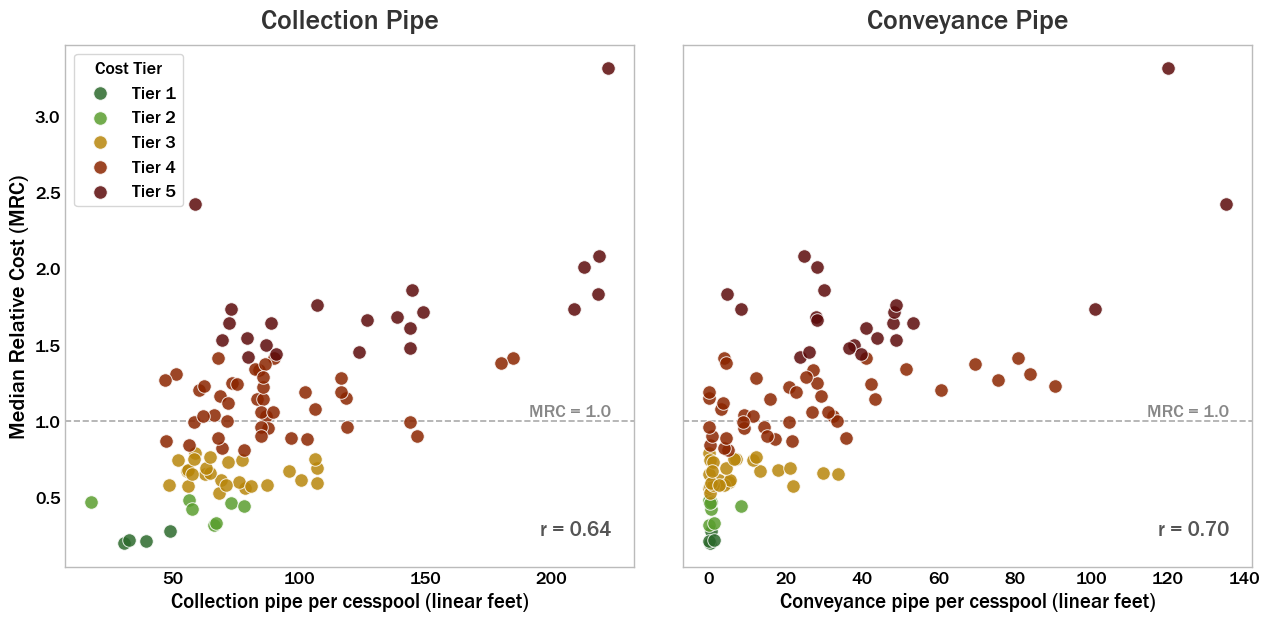

Collection Pipe: r = 0.64
Conveyance Pipe: r = 0.70


In [39]:
# Collection and conveyance pipe per cesspool vs MRC
mpl.rcParams["text.usetex"] = False; plt.rcParams.update({"font.family": "Franklin Gothic Medium", "font.size": 16})
mrc_col = "MRC: Median Relative Cost (dimensionless) "; tier_order = ["(1) - $","(2) - $$","(3) - $$$","(4) - $$$$","(5) - $$$$$"]; tier_labels = {"(1) - $":"Tier 1","(2) - $$":"Tier 2","(3) - $$$":"Tier 3","(4) - $$$$":"Tier 4","(5) - $$$$$":"Tier 5"}; tier_colors = {"(1) - $":"#2d6a2d","(2) - $$":"#5a9e2f","(3) - $$$":"#b8860b","(4) - $$$$":"#8b2500","(5) - $$$$$":"#5c0a0a"}
plots = [("Collection_Length_ft", "Collection Pipe", "Collection pipe per cesspool (linear feet)"), ("Conveyance_Length_ft", "Conveyance Pipe", "Conveyance pipe per cesspool (linear feet)")]
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), facecolor="white", sharey=True)

for ax, (xcol, title, xlabel) in zip(axes, plots):
    costs[xcol + "_per_pool"] = costs[xcol] / costs["Connections"]; corr = costs[xcol + "_per_pool"].corr(costs[mrc_col]); ax.set_facecolor("white")
    for tier in tier_order:
        sub = costs[costs["Cost_symbol"].eq(tier)]; ax.scatter(sub[xcol + "_per_pool"], sub[mrc_col], color=tier_colors[tier], s=95, alpha=0.85, zorder=3, label=tier_labels[tier], edgecolors="white", linewidths=0.7)
    ax.axhline(1.0, color="#aaaaaa", linewidth=1.2, linestyle="--", zorder=0); ax.text(0.96, 1.03, "MRC = 1.0", transform=ax.get_yaxis_transform(), ha="right", fontsize=13, color="#888888")
    ax.set_title(title, fontsize=20, fontweight="bold", color="#333333", pad=12); ax.set_xlabel(xlabel, fontsize=15); ax.text(0.96, 0.06, f"r = {corr:.2f}", transform=ax.transAxes, ha="right", fontsize=15, color="#555555")
    ax.yaxis.grid(False); ax.xaxis.grid(False); ax.tick_params(length=0, labelsize=13)
    for s in ["top", "right", "left", "bottom"]: ax.spines[s].set_visible(True); ax.spines[s].set_color("#bbbbbb"); ax.spines[s].set_linewidth(1.0)

axes[0].set_ylabel("Median Relative Cost (MRC)", fontsize=16); axes[1].tick_params(labelleft=False)
axes[0].legend(loc="upper left", frameon=True, fontsize=13, title="Cost Tier", title_fontsize=13)
plt.tight_layout(w_pad=2.2); fig.savefig(os.path.join(".", "Figures", "scatter_collection_conveyance_vs_mrc.png"), dpi=300, bbox_inches="tight", facecolor="white"); plt.show()
for xcol, title, xlabel in plots: print(f"{title}: r = {costs[xcol + '_per_pool'].corr(costs[mrc_col]):.2f}")

### Fig 11

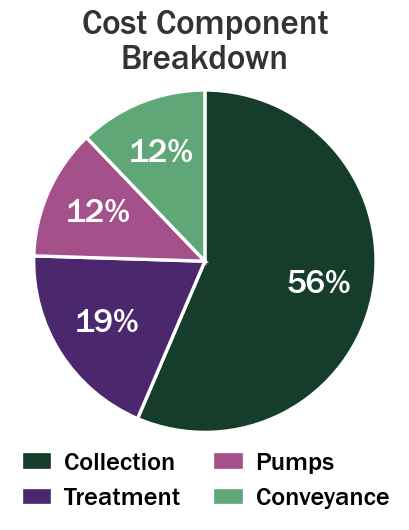

Saved cost_component_breakdown_pie_compact.png
Collection: 56.4%
Treatment: 19.1%
Pumps: 12.4%
Conveyance: 12.2%


In [38]:
# Cost component breakdown pie chart, compact large-font version
mpl.rcParams["text.usetex"] = False; plt.rcParams.update({"font.family": "Franklin Gothic Medium", "font.size": 20})

for c in ["Collection_Cost", "Conveyance_Cost", "Treatment_Cost", "Neighborhood_Pump_Cost", "Regional_Pump_Cost"]: costs[c + "_num"] = costs[c].replace(r"[\$,]", "", regex=True).astype(float)
costs["Pumps_num"] = costs["Neighborhood_Pump_Cost_num"] + costs["Regional_Pump_Cost_num"]

labels = ["Collection", "Treatment", "Pumps", "Conveyance"]; vals = [costs["Collection_Cost_num"].sum(), costs["Treatment_Cost_num"].sum(), costs["Pumps_num"].sum(), costs["Conveyance_Cost_num"].sum()]
colors = ["#163D2B", "#4B286D", "#A4508B", "#5FA777"]

fig, ax = plt.subplots(figsize=(6.2, 5.4), facecolor="white"); ax.set_facecolor("white")
wedges, texts, autotexts = ax.pie(vals, colors=colors, startangle=90, counterclock=False, autopct=lambda p: f"{p:.0f}%", pctdistance=0.68, radius=1.18, wedgeprops=dict(edgecolor="white", linewidth=2.4), textprops=dict(fontsize=24, fontweight="bold", color="white"))
ax.set_title("Cost Component\nBreakdown", fontsize=25, fontweight="bold", color="#333333", pad=8)
ax.legend(wedges, labels, loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False, fontsize=19, handlelength=1.2, columnspacing=1.2, handletextpad=0.45)
ax.set_aspect("equal")

plt.tight_layout(pad=0.3); fig.savefig(os.path.join(".", "Figures", "cost_component_breakdown_pie_compact.png"), dpi=300, bbox_inches="tight", facecolor="white"); plt.show()
print("Saved cost_component_breakdown_pie_compact.png")
for label, val in zip(labels, vals): print(f"{label}: {val / sum(vals) * 100:.1f}%")

### Table A2

In [26]:
import re
import pandas as pd

mrc_col = 'MRC: Median Relative Cost (dimensionless) '

def parse_dollar(v):
    if isinstance(v, str):
        return float(re.sub(r'[$,]', '', v))
    return float(v) if pd.notna(v) else 0

costs['cpc'] = costs['Cost_per_Connection'].apply(parse_dollar)
costs['mrc'] = pd.to_numeric(costs[mrc_col], errors='coerce')
costs['tier'] = costs['Cost_symbol'].str.extract(r'\((\d)\)').astype(float)

median_cpc = costs['cpc'].median()
print(f"Median cost per connection: ${median_cpc:,.0f}")

tier_labels = {
    1: '(1) - $',
    2: '(2) - $$',
    3: '(3) - $$$',
    4: '(4) - $$$$',
    5: '(5) - $$$$$'
}

thresholds = {
    1: ('Under $120,000',    'Under 0.29', 'Under 3x'),
    2: ('$120,000–$200,000', '0.29–0.49',  '3x–5x'),
    3: ('$200,000–$320,000', '0.49–0.78',  '5x–8x'),
    4: ('$320,000–$560,000', '0.78–1.37',  '8x–14x'),
    5: ('Over $560,000',     'Over 1.37',  'Over 14x'),
}

rows = []
for t in [1, 2, 3, 4, 5]:
    sub = costs[costs['tier'] == t]
    rows.append({
        'Rating':                          tier_labels[t],
        'Cost per Connection':             thresholds[t][0],
        'MRC Range':                       thresholds[t][1],
        'Approx. Multiple of Onsite Alt.': thresholds[t][2],
        'Areas':                           len(sub),
        'Share':                           f"{len(sub)/len(costs)*100:.0f}%"
    })

rows.append({
    'Rating':                          'Total',
    'Cost per Connection':             '',
    'MRC Range':                       '',
    'Approx. Multiple of Onsite Alt.': '',
    'Areas':                           len(costs),
    'Share':                           '100%'
})

tier_table = pd.DataFrame(rows)
print(f"\nTotal areas: {len(costs)}")
tier_table

Median cost per connection: $396,639

Total areas: 103


,Rating,Cost per Connection,MRC Range,Approx. Multiple of Onsite Alt.,Areas,Share
0,(1) - $,"Under $120,000",Under 0.29,Under 3x,4,4%
1,(2) - $$,"$120,000–$200,000",0.29–0.49,3x–5x,7,7%
2,(3) - $$$,"$200,000–$320,000",0.49–0.78,5x–8x,26,25%
3,(4) - $$$$,"$320,000–$560,000",0.78–1.37,8x–14x,44,43%
4,(5) - $$$$$,"Over $560,000",Over 1.37,Over 14x,22,21%
5,Total,,,,103,100%


### Golden Figure E3 and 10

Saved.


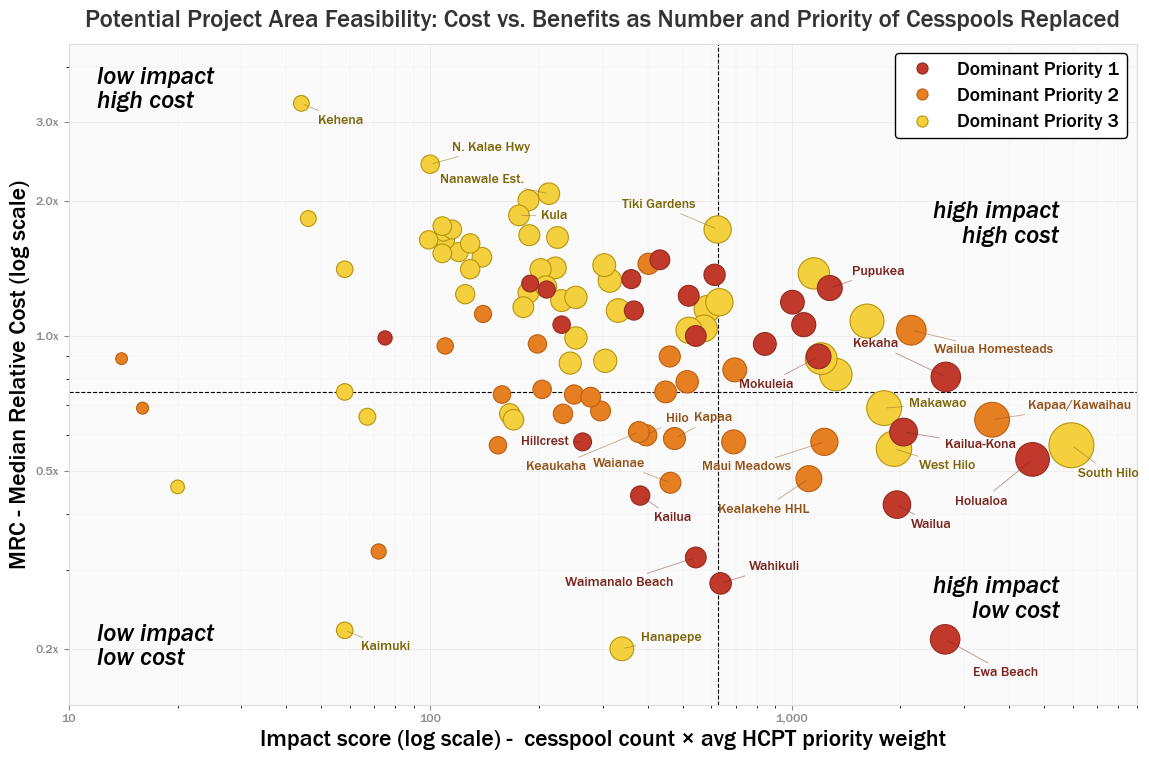

In [30]:
#### ── BUILD DATAFRAME ───────────────────────────────────────────────────────────
df = master[["UID", "Name", "Status", "Priority_1_Cesspool_Count", "Priority_2_Cesspool_Count", "Priority_3_Cesspool_Count", "Total_Cesspools", "Cost_symbol"]].copy()
df = df.rename(columns={"Priority_1_Cesspool_Count": "p1", "Priority_2_Cesspool_Count": "p2", "Priority_3_Cesspool_Count": "p3", "Total_Cesspools": "total"})


df[["p1","p2","p3","total"]] = df[["p1","p2","p3","total"]].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
df = df[df["total"] > 0].copy()

# Average priority weight: P1=3, P2=2, P3=1
df["avg_priority_weight"] = (df["p1"]*3 + df["p2"]*2 + df["p3"]*1) / df["total"]

# Impact score
df["impact"] = df["total"] * df["avg_priority_weight"]

# Dominant priority: whichever of p1/p2/p3 is largest
df["dom"] = df[["p1","p2","p3"]].values.argmax(axis=1) + 1  # 1, 2, or 3

# Cost tier
tier_map = {"(1) - $": 1, "(2) - $$": 2, "(3) - $$$": 3, "(4) - $$$$": 4, "(5) - $$$$$": 5}
df["tier"] = df["Cost_symbol"].map(tier_map)

# Planning status shorthand
def status_short(s):
    if "Planned" in str(s): return "P"
    if "Evaluation" in str(s): return "E"
    return "N"
df["status"] = df["Status"].apply(status_short)

# Join MRC from costs
mrc_col = "MRC: Median Relative Cost (dimensionless) "  # trailing space in original
costs_slim = costs[["UID", mrc_col]].copy()
costs_slim[mrc_col] = pd.to_numeric(costs_slim[mrc_col], errors="coerce")
costs_slim = costs_slim.rename(columns={mrc_col: "mrc"})
df = df.merge(costs_slim, on="UID", how="left")
df = df.dropna(subset=["mrc"])

#probably dont need these
#x_quad = 10 ** np.median(np.log10(df["impact"][df["impact"] > 0])); 
#y_quad = 10 ** np.median(np.log10(df["mrc"][df["mrc"] > 0]))
avg_impact = df["impact"].mean()


# ── LABEL CONFIG ─────────────────────────────────────────────────────────────
# uid -> (label text, dx points, dy points, horizontal alignment)
# Adjust dx/dy if labels overlap in your environment

label_cfg = {
    "O-11": ("Ewa Beach", 20, -24, "left"),
    "H-17": ("Holualoa", -18, -30, "right"),
    "H-4": ("Kailua-Kona", 30, -9, "left"),
    "K-5": ("Wailua", 10, -14, "left"),
    "K-1": ("Kekaha", -34, 24, "right"),
    "H-14": ("South Hilo", 5, -20, "left"),
    "K-2": ("Kapaa/Kawaihau", 26, 10, "left"),
    "H-12": ("West Hilo", 18, -12, "left"),
    "K-21": ("Hanapepe", 14, 8, "left"),
    "O-12": ("Kaimuki", 12, -12, "left"),
    "M-4": ("Wahikuli", 20, 12, "left"),
    "O-1": ("Waimanalo Beach", -16, -18, "right"),
    "O-2": ("Kailua", 10, -16, "left"),
    "H-21": ("Kehena", 12, -12, "left"),
    "Mo-2": ("N. Kalae Hwy", 16, 12, "left"),
    "H-19": ("Nanawale Est.", -18, 10, "right"),
    "K-7": ("Wailua Homesteads", 16, -14, "left"),
    "O-20": ("Pupukea", 16, 12, "left"),
    "O-8": ("Mokuleia", -18, -20, "right"),
    "H-5": ("Kealakehe HHL", 0, -22, "right"),
    "M-15": ("Makawao", 18, 3, "left"),
    "M-7": ("Maui Meadows", -24, -18, "right"),
    "M-8": ("Kula", 16, 0, "left"),
    "H-38": ("Tiki Gardens", -16, 18, "right"),
    "K-1": ("Kekaha", -34, 24, "right"),
    "H-15": ("Keaukaha", -38, -25, "right"),
    "H-13": ("Hilo", 14, 12, "left"),
    "O-10": ("Waianae", -18, 14, "right"),
    "K-4": ("Kapaa", 14, 15, "left"),
    "H-3": ("Hillcrest", -10, 0, "right"),
}




# ── COLORS ───────────────────────────────────────────────────────────────────
dot_color  = {1: "#C0392B", 2: "#E67E22", 3: "#F4D03F"}
edge_color = {1: "#922B21", 2: "#BA6010", 3: "#B7950B"}
text_color = {1: "#7B241C", 2: "#935116", 3: "#7D6608"}


df["bubble_size"] = 35 + np.sqrt(df["total"]) * 14
# ── PLOT ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAFA")

ax.set_xscale("log")
ax.set_yscale("log")

# Reference lines
ax.axhline(0.75,  color="000000", linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(avg_impact, color="000000", linewidth=0.8, linestyle="--", zorder=1)

# Plot points — P3 first so P1 renders on top
for dom in [3, 2, 1]:
    subset = df[df["dom"] == dom]
    ax.scatter(
        subset["impact"], subset["mrc"],
        s=subset["bubble_size"],
        color=dot_color[dom],
        edgecolors=edge_color[dom],
        linewidths=0.8,
        zorder=3,
        label=f"Priority {dom}",
    )

# Labels
for _, row in df.iterrows():
    uid = row["UID"]
    if uid not in label_cfg:
        continue
    label_text, dx, dy, ha = label_cfg[uid]
    dom = row["dom"]
    ax.annotate(
        label_text,
        xy=(row["impact"], row["mrc"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        color=text_color[dom],
        ha=ha,
        va="center",
        zorder=5,
        arrowprops=dict(
            arrowstyle="-",
            color=text_color[dom],
            lw=0.6,
            alpha=0.5,
        ),
    )

# ── AXES ─────────────────────────────────────────────────────────────────────
ax.set_xlim(10, 9000)
ax.set_ylim(0.15, 4.5)
ax.set_yticks([0.2, 0.5, 1, 2, 3])

ax.set_xlabel("Impact score (log scale) -  cesspool count × avg HCPT priority weight",fontsize=17, color="black")
ax.set_ylabel("MRC - Median Relative Cost (log scale)" , fontsize=17, color="black")

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}" if x >= 1 else ""))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}x"))

for spine in ax.spines.values():
    spine.set_edgecolor("#DDDDDD")
ax.tick_params(colors="#888888", labelsize=9)
ax.grid(True, which="major", color="#E8E8E8", linewidth=0.5, zorder=0)
ax.grid(True, which="minor", color="#F0F0F0", linewidth=0.3, zorder=0)

# ── QUADRANT LABELS ──────────────────────────────────────────────────────────
ax.text(5500, 0.23, "high impact\nlow cost",  fontsize=18, color="black", ha="right", va="bottom", style="italic")
ax.text(12,   0.18, "low impact\nlow cost",   fontsize=18, color="black", ha="left",  va="bottom", style="italic")
ax.text(5500, 2.0,  "high impact\nhigh cost", fontsize=18, color="black", ha="right", va="top",    style="italic")
ax.text(12,   4.0,  "low impact\nhigh cost",  fontsize=18, color="black", ha="left",  va="top",    style="italic")

# ── LEGEND ───────────────────────────────────────────────────────────────────
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=dot_color[d], markeredgecolor=edge_color[d], markeredgewidth=0.8, markersize=8, label=f"Dominant Priority {d}")
    for d in [1, 2, 3]
]
leg = ax.legend(handles=legend_handles, fontsize=14, frameon=True, framealpha=1, edgecolor="#000000", loc="upper right")
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_facecolor("white")

ax.set_title("Potential Project Area Feasibility: Cost vs. Benefits as Number and Priority of Cesspools Replaced", fontsize=18, fontweight="normal", color="#333333", pad=12)

plt.tight_layout()
plt.savefig(os.path.join(".", "Figures", "impact_mrc_chart.png"), dpi=180, bbox_inches="tight")
plt.savefig(os.path.join(".", "Figures", "impact_mrc_chart.pdf"), bbox_inches="tight")
print("Saved.")
plt.show()

### Table 6

In [31]:
# Merge master and costs
mrc_col = 'MRC: Median Relative Cost (dimensionless) '
df = master.merge(costs[['UID', mrc_col, 'Cost_symbol']], on='UID', how='left', suffixes=('', '_costs'))

# Calculate % Priority 1
df['pct_p1'] = (df['Priority_1_Cesspool_Count'] / df['Total_Cesspools'] * 100).round(0).astype(int).astype(str) + '%'

# Clean up Cost_symbol to just dollar signs -- use costs version
df['Cost_tier'] = df['Cost_symbol_costs'].str.extract(r'\(.\) - (\$+)')

# Clean up planning status to just the letter
df['Status_short'] = df['Status'].str.extract(r'\((\w)\)')

# Round MRC
df[mrc_col] = df[mrc_col].round(2)

# Selected UIDs in display order
selected_uids = ['O-11', 'O-1', 'O-2', 'M-4', 'K-21', 'K-5', 'H-5', 'H-17']

# Filter and order
table = df[df['UID'].isin(selected_uids)].set_index('UID').loc[selected_uids].reset_index()

# Island name cleanup
island_map = {'Hawaii': "Hawai'i", 'Oahu': "O'ahu", 'Kauai': "Kaua'i", 'Maui': 'Maui'}
table['island'] = table['island'].map(island_map)

# Build display table
display_table = table[['Name', 'island', 'UID', 'Status_short', 'pct_p1', 
                        'Total_Cesspools', mrc_col, 'Cost_tier']].copy()

display_table.columns = ['Area', 'Island', 'UID', 'Planning Status', 
                         '% Priority 1', 'Total Cesspools', 'MRC', 'Cost Tier']

display_table

,Area,Island,UID,Planning Status,% Priority 1,Total Cesspools,MRC,Cost Tier
0,Ewa Beach,O'ahu,O-11,P,100%,886,0.21,$
1,Waimanalo Beach,O'ahu,O-1,E,100%,181,0.32,$$
2,Kailua,O'ahu,O-2,E,100%,127,0.44,$$
3,Wahikuli,Maui,M-4,E,100%,212,0.28,$
4,Hanapepe,Kaua'i,K-21,N,0%,339,0.20,$
5,Wailua,Kaua'i,K-5,N,100%,652,0.42,$$
6,Kealakehe HHL,Hawai'i,H-5,N,22%,503,0.48,$$
7,Holualoa,Hawai'i,H-17,N,100%,1549,0.53,$$$


### Fig A3

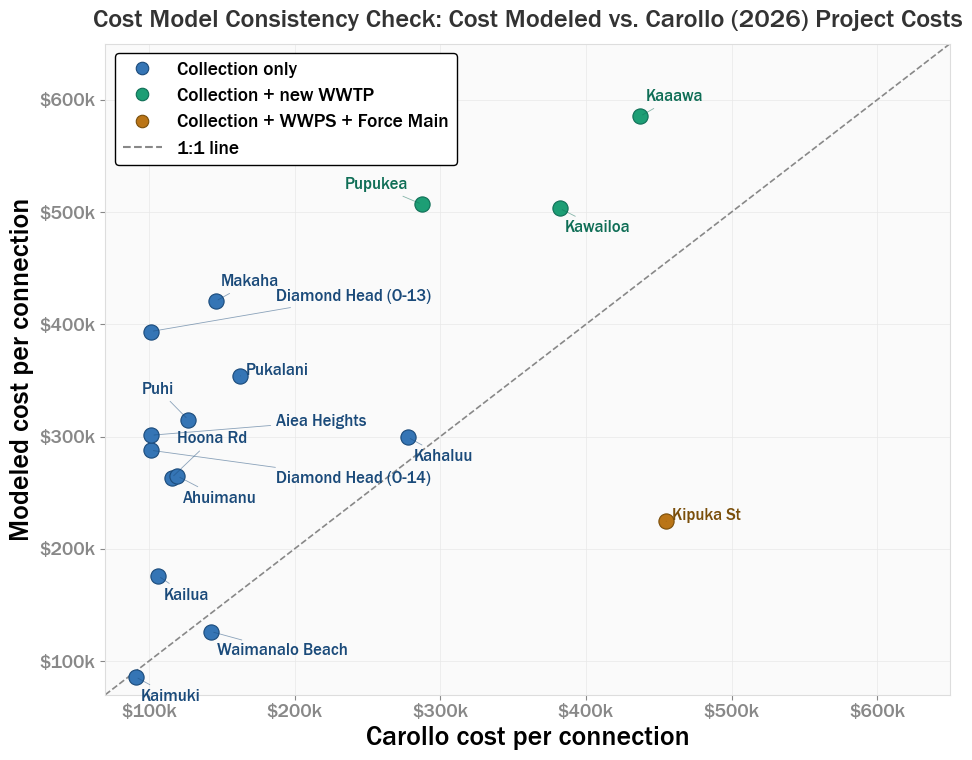

In [37]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

data = [
    {'name': 'Kaimuki',             'carollo': 90789,  'ours': 85913,  'scope': 'Collection only'},
    {'name': 'Diamond Head (O-13)', 'carollo': 101149, 'ours': 393543, 'scope': 'Collection only'},
    {'name': 'Diamond Head (O-14)', 'carollo': 101149, 'ours': 287792, 'scope': 'Collection only'},
    {'name': 'Aiea Heights',        'carollo': 101538, 'ours': 301172, 'scope': 'Collection only'},
    {'name': 'Kailua',              'carollo': 106358, 'ours': 175898, 'scope': 'Collection only'},
    {'name': 'Hoona Rd',            'carollo': 115584, 'ours': 263370, 'scope': 'Collection only'},
    {'name': 'Ahuimanu',            'carollo': 119549, 'ours': 264790, 'scope': 'Collection only'},
    {'name': 'Puhi',                'carollo': 126837, 'ours': 315095, 'scope': 'Collection only'},
    {'name': 'Waimanalo Beach',     'carollo': 142606, 'ours': 126278, 'scope': 'Collection only'},
    {'name': 'Makaha',              'carollo': 145794, 'ours': 420560, 'scope': 'Collection only'},
    {'name': 'Pukalani',            'carollo': 162804, 'ours': 354049, 'scope': 'Collection only'},
    {'name': 'Kahaluu',             'carollo': 277711, 'ours': 299432, 'scope': 'Collection only'},
    {'name': 'Pupukea',             'carollo': 287368, 'ours': 506890, 'scope': 'Collection + new WWTP'},
    {'name': 'Kawailoa',            'carollo': 382000, 'ours': 503265, 'scope': 'Collection + new WWTP'},
    {'name': 'Kaaawa',              'carollo': 437168, 'ours': 585315, 'scope': 'Collection + new WWTP'},
    {'name': 'Kipuka St',           'carollo': 455140, 'ours': 224532, 'scope': 'Collection + WWPS + Force Main'},
]

df = pd.DataFrame(data)

dot_color  = {
    'Collection only':              '#3575b5',
    'Collection + new WWTP':        '#1D9E75',
    'Collection + WWPS + Force Main': '#BA7517'
}
edge_color = {
    'Collection only':              '#1a4a7a',
    'Collection + new WWTP':        '#0f6e56',
    'Collection + WWPS + Force Main': '#7a4e0a'
}
text_color = {
    'Collection only':              '#1a4a7a',
    'Collection + new WWTP':        '#0f6e56',
    'Collection + WWPS + Force Main': '#7a4e0a'
}

label_cfg = {
    'Kaimuki':             ('Kaimuki',              4,    -14, 'left'),
    'Diamond Head (O-13)': ('Diamond Head (O-13)',  90,    25, 'left'),
    'Diamond Head (O-14)': ('Diamond Head (O-14)',  90,   -20, 'left'),
    'Aiea Heights':        ('Aiea Heights',         90,    10, 'left'),
    'Kailua':              ('Kailua',               4,   -14, 'left'),
    'Hoona Rd':            ('Hoona Rd',             4,    28, 'left'),
    'Ahuimanu':            ('Ahuimanu',             4,   -16, 'left'),
    'Puhi':                ('Puhi',                -10,   22, 'right'),
    'Waimanalo Beach':     ('Waimanalo Beach',      4,   -14, 'left'),
    'Makaha':              ('Makaha',               4,    14, 'left'),
    'Pukalani':            ('Pukalani',             4,     4, 'left'),
    'Kahaluu':             ('Kahaluu',              4,   -14, 'left'),
    'Pupukea':             ('Pupukea',             -10,   14, 'right'),
    'Kawailoa':            ('Kawailoa',             4,   -14, 'left'),
    'Kaaawa':              ('Kaaawa',               4,    14, 'left'),
    'Kipuka St':           ('Kipuka St',            4,     4, 'left'),
}

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('#FAFAFA')

# 1:1 line
lim = [70000, 650000]
ax.plot(lim, lim, '--', color='#888888', linewidth=1.2, label='1:1 line', zorder=2)

# Plot points
for scope in ['Collection only', 'Collection + new WWTP', 'Collection + WWPS + Force Main']:
    subset = df[df['scope'] == scope]
    ax.scatter(subset['carollo'], subset['ours'],
               s=120,
               color=dot_color[scope],
               edgecolors=edge_color[scope],
               linewidths=0.8,
               zorder=3,
               label=scope)

# Labels
for _, row in df.iterrows():
    name = row['name']
    if name not in label_cfg:
        continue
    label_text, dx, dy, ha = label_cfg[name]
    scope = row['scope']
    ax.annotate(
        label_text,
        xy=(row['carollo'], row['ours']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=12,
        color=text_color[scope],
        ha=ha,
        va='center',
        zorder=5,
        arrowprops=dict(
            arrowstyle='-',
            color=text_color[scope],
            lw=0.6,
            alpha=0.5,
        ),
    )

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Carollo cost per connection', fontsize=20, color='black')
ax.set_ylabel('Modeled cost per connection', fontsize=20, color='black')
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

for spine in ax.spines.values():
    spine.set_edgecolor('#DDDDDD')
ax.tick_params(colors='#888888', labelsize=14)
ax.grid(True, which='major', color='#E8E8E8', linewidth=0.5, zorder=0)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=dot_color[s],
               markeredgecolor=edge_color[s],
               markeredgewidth=0.8, markersize=9, label=s)
    for s in ['Collection only', 'Collection + new WWTP', 'Collection + WWPS + Force Main']
] + [
    plt.Line2D([0], [0], linestyle='--', color='#888888', label='1:1 line')
]
leg = ax.legend(handles=legend_handles, fontsize=14, frameon=True,
                framealpha=1, edgecolor='#000000', loc='upper left')
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_facecolor('white')

ax.set_title('Cost Model Consistency Check: Cost Modeled vs. Carollo (2026) Project Costs',
             fontsize=19, fontweight='normal', color='#333333', pad=12)

plt.tight_layout()
plt.savefig(os.path.join(".", "Figures", 'carollo_validation_scatter.png'), dpi=180, bbox_inches='tight')
plt.show()

# Unused Figures and tables

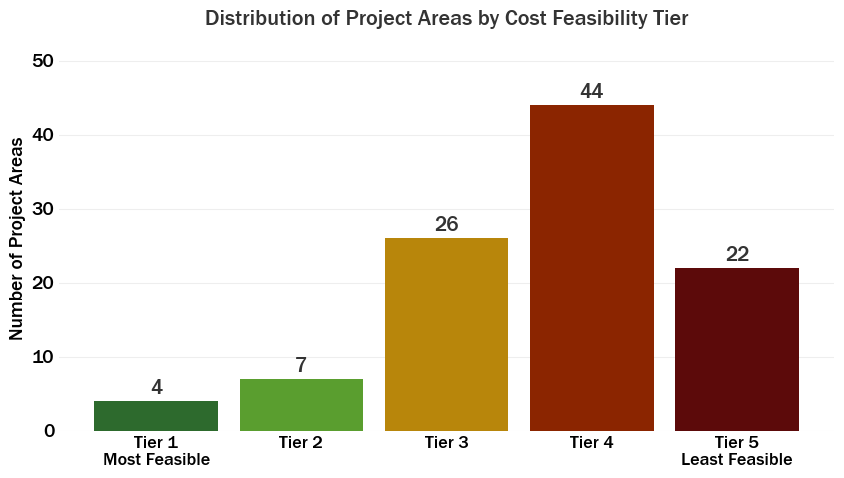

In [9]:
mpl.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "Franklin Gothic Medium"
plt.rcParams["font.size"] = 14

tier_order  = ["(1) - $", "(2) - $$", "(3) - $$$", "(4) - $$$$", "(5) - $$$$$"]
tier_labels = ["Tier 1\nMost Feasible", "Tier 2", "Tier 3", "Tier 4", "Tier 5\nLeast Feasible"]
tier_colors = ["#2d6a2d", "#5a9e2f", "#b8860b", "#8b2500", "#5c0a0a"]

counts = costs["Cost_symbol"].value_counts().reindex(tier_order)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.bar(range(len(tier_labels)), counts.values, color=tier_colors,
              edgecolor="none", width=0.85)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            str(val), ha="center", va="bottom", fontsize=15, fontweight="bold", color="#333333")

ax.set_xticks(range(len(tier_labels)))
ax.set_xticklabels(tier_labels, fontsize=13)
ax.set_ylabel("Number of Project Areas", fontsize=14)
ax.set_title("Distribution of Project Areas by Cost Feasibility Tier", fontsize=16, fontweight="bold", color="#333333", pad=15)
ax.set_ylim(0, counts.max() + 8)
ax.yaxis.grid(True, color="#eeeeee", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="both", length=0)

fig.savefig(os.path.join(".", "Figures", "cost_tier_distribution.png"), dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


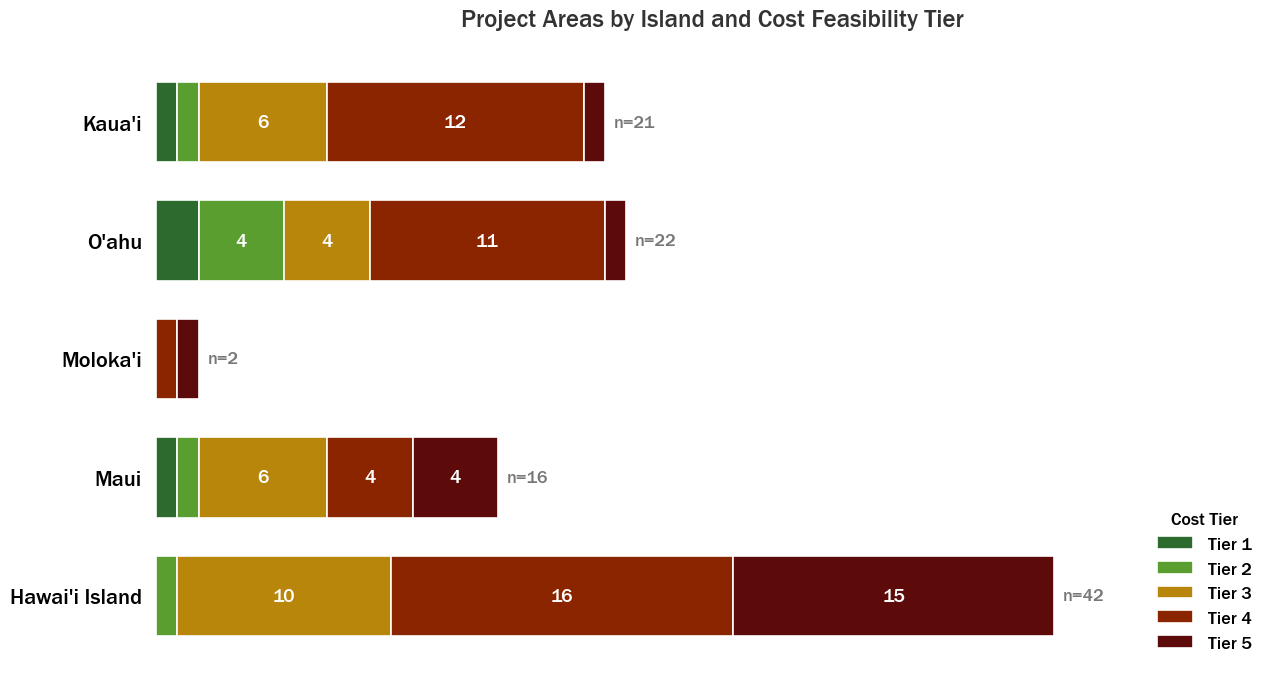

Saved stacked_island_tiers.png


In [17]:
island_order  = ['Hawaii', 'Maui', 'Molokai', 'Oahu', 'Kauai']
island_labels = ["Hawai'i Island", 'Maui', "Moloka'i", "O'ahu", "Kaua'i"]
tier_labels   = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4', 'Tier 5']
tier_colors   = ['#2d6a2d','#5a9e2f','#b8860b','#8b2500','#5c0a0a']

merged_island = costs.merge(master[['UID','island','Cost_symbol']], on='UID', suffixes=('_costs','_master'))
tier_order = ['(1) - $','(2) - $$','(3) - $$$','(4) - $$$$','(5) - $$$$$']

data = {}
for isl in island_order:
    sub = merged_island[merged_island['island'] == isl]
    counts = sub.groupby('Cost_symbol_master').size().reindex(tier_order, fill_value=0)
    data[isl] = counts.tolist()

totals = [sum(data[isl]) for isl in island_order]

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bottoms = np.zeros(len(island_order))
for i, (color, label) in enumerate(zip(tier_colors, tier_labels)):
    values = [data[isl][i] for isl in island_order]
    ax.barh(range(len(island_order)), values, left=bottoms, color=color,
            edgecolor='white', linewidth=1.2, height=0.68, label=label)
    for j, (val, bot) in enumerate(zip(values, bottoms)):
        if val >= 3:
            ax.text(bot + val/2, j, str(val), ha='center', va='center',
                    fontsize=14, fontweight='bold', color='white')
    bottoms += np.array(values)

for j, total in enumerate(totals):
    ax.text(total + 0.4, j, f'n={total}', ha='left', va='center',
            fontsize=13, color='#777777')

ax.set_yticks(range(len(island_labels)))
ax.set_yticklabels(island_labels, fontsize=16)
ax.yaxis.set_tick_params(length=0, pad=10)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

ax.set_title("Project Areas by Island and Cost Feasibility Tier",
             fontsize=18, fontweight='bold', color='#333333', pad=18)

ax.set_xlim(0, 52)
ax.set_ylim(-0.6, len(island_order) - 0.4)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)

ax.legend(loc='lower right', frameon=False, fontsize=13,
          title='Cost Tier', title_fontsize=13)

plt.tight_layout()
fig.savefig("stacked_island_tiers.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved stacked_island_tiers.png")

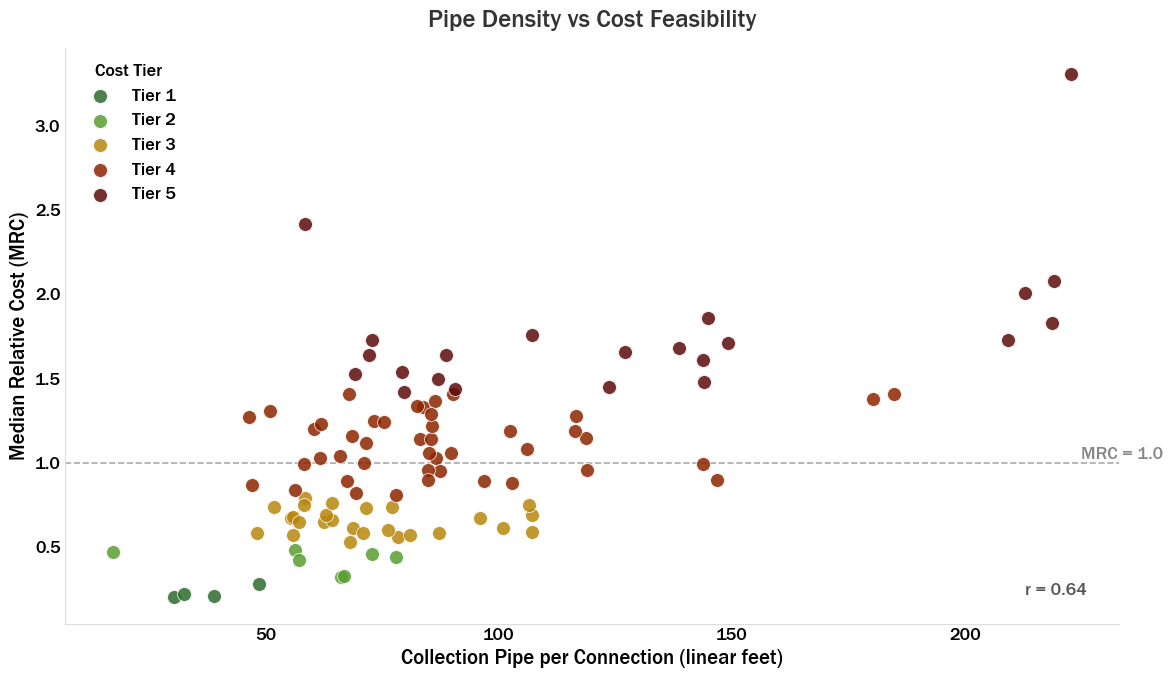

Saved pipe_density_vs_mrc.png


In [21]:
mrc_col = 'MRC: Median Relative Cost (dimensionless) '
tier_order  = ['(1) - $','(2) - $$','(3) - $$$','(4) - $$$$','(5) - $$$$$']
tier_labels_map = {'(1) - $':'Tier 1','(2) - $$':'Tier 2','(3) - $$$':'Tier 3',
                   '(4) - $$$$':'Tier 4','(5) - $$$$$':'Tier 5'}
tier_colors = {'(1) - $':'#2d6a2d','(2) - $$':'#5a9e2f','(3) - $$$':'#b8860b',
               '(4) - $$$$':'#8b2500','(5) - $$$$$':'#5c0a0a'}

costs['coll_lf_per_conn'] = costs['Collection_Length_ft'] / costs['Connections']
corr = costs['coll_lf_per_conn'].corr(costs[mrc_col])

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for tier in tier_order:
    sub = costs[costs['Cost_symbol'] == tier]
    ax.scatter(sub['coll_lf_per_conn'], sub[mrc_col],
               color=tier_colors[tier], s=100, alpha=0.85, zorder=3,
               label=tier_labels_map[tier], edgecolors='white', linewidths=0.6)

ax.axhline(1.0, color='#aaaaaa', linewidth=1.2, linestyle='--', zorder=0)
ax.text(costs['coll_lf_per_conn'].max() * 1.01, 1.02, 'MRC = 1.0',
        fontsize=13, color='#888888')

ax.set_xlabel('Collection Pipe per Connection (linear feet)', fontsize=15)
ax.set_ylabel('Median Relative Cost (MRC)', fontsize=15)
ax.set_title('Pipe Density vs Cost Feasibility', fontsize=18,
             fontweight='bold', color='#333333', pad=15)
ax.legend(loc='upper left', frameon=False, fontsize=13,
          title='Cost Tier', title_fontsize=13)
ax.text(0.97, 0.05, f'r = {corr:.2f}', transform=ax.transAxes,
        ha='right', fontsize=13, color='#555555')

ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')
ax.tick_params(length=0, labelsize=13)

plt.tight_layout()
fig.savefig('pipe_density_vs_mrc.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved pipe_density_vs_mrc.png')

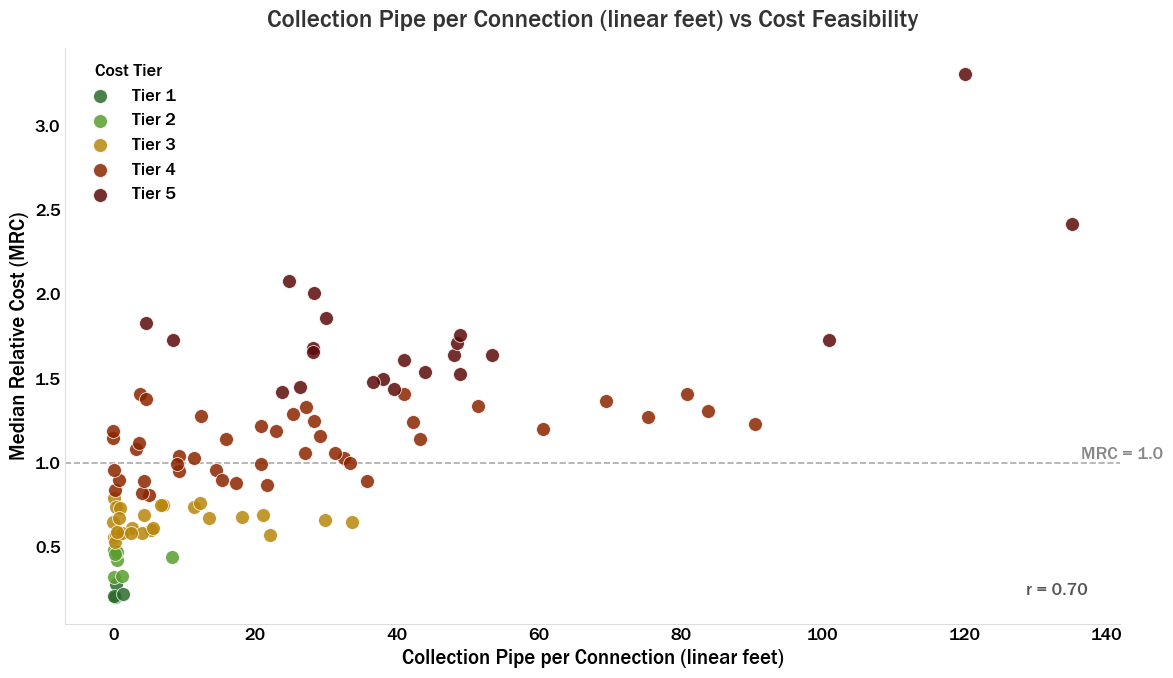

r = 0.70


In [22]:
# Change this one variable to swap the cost component
X_COMPONENT = 'Conveyance_Length_ft'  # options below:
# 'Collection_Length_ft'
# 'Conveyance_Length_ft'
# 'Neighborhood_Pump_Stations'
# 'Regional_Pump_Stations'
# 'Mean_slope_pct'
# 'Basalt_fraction'

X_LABEL = 'Collection Pipe per Connection (linear feet)'  # update to match

mrc_col = 'MRC: Median Relative Cost (dimensionless) '
tier_order  = ['(1) - $','(2) - $$','(3) - $$$','(4) - $$$$','(5) - $$$$$']
tier_labels_map = {'(1) - $':'Tier 1','(2) - $$':'Tier 2','(3) - $$$':'Tier 3',
                   '(4) - $$$$':'Tier 4','(5) - $$$$$':'Tier 5'}
tier_colors = {'(1) - $':'#2d6a2d','(2) - $$':'#5a9e2f','(3) - $$$':'#b8860b',
               '(4) - $$$$':'#8b2500','(5) - $$$$$':'#5c0a0a'}

costs['x_var'] = costs[X_COMPONENT] / costs['Connections']
corr = costs['x_var'].corr(costs[mrc_col])

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for tier in tier_order:
    sub = costs[costs['Cost_symbol'] == tier]
    ax.scatter(sub['x_var'], sub[mrc_col],
               color=tier_colors[tier], s=100, alpha=0.85, zorder=3,
               label=tier_labels_map[tier], edgecolors='white', linewidths=0.6)

ax.axhline(1.0, color='#aaaaaa', linewidth=1.2, linestyle='--', zorder=0)
ax.text(costs['x_var'].max() * 1.01, 1.02, 'MRC = 1.0', fontsize=13, color='#888888')

ax.set_xlabel(X_LABEL, fontsize=15)
ax.set_ylabel('Median Relative Cost (MRC)', fontsize=15)
ax.set_title(f'{X_LABEL} vs Cost Feasibility', fontsize=18,
             fontweight='bold', color='#333333', pad=15)
ax.legend(loc='upper left', frameon=False, fontsize=13,
          title='Cost Tier', title_fontsize=13)
ax.text(0.97, 0.05, f'r = {corr:.2f}', transform=ax.transAxes,
        ha='right', fontsize=13, color='#555555')

ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')
ax.tick_params(length=0, labelsize=13)

plt.tight_layout()
fig.savefig(f'scatter_{X_COMPONENT}_vs_mrc.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'r = {corr:.2f}')


In [36]:
mrc_col = 'MRC: Median Relative Cost (dimensionless) '
df = master.merge(costs[['UID', mrc_col, 'Cost_symbol']], on='UID', how='left', suffixes=('', '_costs'))
df['tier'] = df['Cost_symbol_costs'].str.extract(r'\((\d)\)').astype(float)

# Status flags
df['is_P'] = df['Status'].str.contains(r'\(P\)', regex=True)
df['is_E'] = df['Status'].str.contains(r'\(E\)', regex=True)
df['is_N'] = df['Status'].str.contains(r'\(N\)', regex=True)

wwtp_group = df.groupby('WWTP_1_Name').agg(
    Island=('island', 'first'),
    Areas=('UID', 'count'),
    Total_Cesspools=('Total_Cesspools', 'sum'),
    Planned=('is_P', 'sum'),
    Under_Eval=('is_E', 'sum'),
    No_Plans=('is_N', 'sum'),
    Capacity=('WWTP_Capacity', 'first'),
).reset_index()

# Filter to WWTPs with 2+ dependent areas, sort by cesspools
wwtp_table = wwtp_group[wwtp_group['Areas'] >= 2].sort_values('Total_Cesspools', ascending=False)

wwtp_table.columns = ['Receiving Facility', 'Island', 'Dependent Areas', 
                       'Total Cesspools', 'Planned', 'Under Evaluation', 
                       'No Active Plans', 'Capacity Status']

# Island name cleanup
island_map = {'Hawaii': "Hawai'i", 'Maui': 'Maui', 
              'Molokai': "Moloka'i", 'Oahu': "O'ahu", 'Kauai': "Kaua'i"}
wwtp_table['Island'] = wwtp_table['Island'].map(island_map)

# Replace 0 with dash for display
status_cols = ['Planned', 'Under Evaluation', 'No Active Plans']
wwtp_table[status_cols] = wwtp_table[status_cols].replace(0, '-')

wwtp_table

,Receiving Facility,Island,Dependent Areas,Total Cesspools,Planned,Under Evaluation,No Active Plans,Capacity Status
1,Hilo WWTP,Hawai'i,7,8153,-,-,7,Limited Capacity
24,Wailua WWTP,Kaua'i,6,3831,-,-,6,No
21,Pukalani WWTP,Maui,2,3009,-,-,2,No
8,Kealakehe,Hawai'i,5,2968,-,-,5,Limited Capacity
19,Poipu Wastewater Reclamation Facility,Kaua'i,5,1240,-,-,5,Yes
27,"Waimea Wastewater Company, Inc.",Hawai'i,3,1093,-,3,-,Unknown
17,Paalaa Kai WWTP,O'ahu,3,912,-,3,-,No
3,Honokaa WWTP,Hawai'i,2,746,-,-,2,No
14,Lihue-Puhi Wastewater Facility,Kaua'i,2,605,-,-,2,No
22,Sand Island WWTP/Synagro,O'ahu,5,517,-,4,1,Yes
